# 🏀 NBA Salary Predictor — Previsão de Salários da NBA

## Problema de Negócio
Com base nas estatísticas de desempenho da temporada 2022-23, este modelo
prevê o salário anual de um jogador da NBA.

Isso é útil para:
- Times que precisam tomar decisões estratégicas de contratação
- Agentes esportivos que negociam contratos com base em desempenho real
- Análise de jogadores sub ou supervalorizados no mercado

## Variável Alvo
`Salary` — salário anual do jogador em dólares (valor numérico contínuo)

## Dataset
NBA Players Stats and Salaries — Temporada 2022-23
- 467 registros
- 52 colunas
- Fonte: Kaggle

In [1]:
# ============================================================
# NBA Salary Predictor
# Célula 1: Importação das bibliotecas
# ============================================================

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Versionamento do modelo
import joblib
import json
import os
from datetime import datetime

# Configurações visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Ignorar warnings desnecessários
import warnings
warnings.filterwarnings("ignore")

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [2]:
# ============================================================
# Célula 2: Fase 1 — Carregar o Dataset
# ============================================================

# Carregando o dataset do NBA 2022-23
df = pd.read_csv("nba_2022-23_all_stats_with_salary.csv")

print(f"✅ Dataset carregado com sucesso!")
print(f"   Linhas    : {df.shape[0]}")
print(f"   Colunas   : {df.shape[1]}")
print(f"\n📋 Primeiros registros:")
print(df.head())

✅ Dataset carregado com sucesso!
   Linhas    : 467
   Colunas   : 52

📋 Primeiros registros:
   Unnamed: 0        Player Name    Salary Position  Age     Team  GP  GS  \
0           0      Stephen Curry  48070014       PG   34      GSW  56  56   
1           1          John Wall  47345760       PG   32      LAC  34   3   
2           2  Russell Westbrook  47080179       PG   34  LAL/LAC  73  24   
3           3       LeBron James  44474988       PF   38      LAL  55  54   
4           4       Kevin Durant  44119845       PF   34  BRK/PHO  47  47   

     MP    FG  ...  TOV%  USG%  OWS  DWS   WS  WS/48  OBPM  DBPM  BPM  VORP  
0  34.7  10.0  ...  12.5  31.0  5.8  2.0  7.8  0.192   7.5   0.1  7.5   4.7  
1  22.2   4.1  ...  17.1  27.0 -0.4  0.7  0.3  0.020  -0.8  -0.4 -1.2   0.1  
2  29.1   5.9  ...  18.4  27.7 -0.6  2.6  1.9  0.044   0.3  -0.1  0.2   1.2  
3  35.5  11.1  ...  11.6  33.3  3.2  2.4  5.6  0.138   5.5   0.6  6.1   4.0  
4  35.6  10.3  ...  13.4  30.7  4.7  2.1  6.8  0.194 

In [3]:
# ============================================================
# Célula 3: Fase 1 — Inspeção Inicial do Dataset
# ============================================================

print("=== INFORMAÇÕES GERAIS DO DATASET ===")
print("-" * 45)
print(f"  Dimensões        : {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"  Memória utilizada: {df.memory_usage().sum() / 1024:.2f} KB")
print("-" * 45)

print("\n=== TIPOS DE DADOS POR COLUNA ===")
print("-" * 45)
print(df.dtypes)
print("-" * 45)

print("\n=== VALORES NULOS POR COLUNA ===")
print("-" * 45)
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df)) * 100
nulos_df = pd.DataFrame({
    "Nulos"      : nulos,
    "Percentual" : nulos_pct.round(2)
})
# Mostrar apenas colunas que têm nulos
print(nulos_df[nulos_df["Nulos"] > 0])
print("-" * 45)

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df.describe().round(2))

=== INFORMAÇÕES GERAIS DO DATASET ===
---------------------------------------------
  Dimensões        : 467 linhas x 52 colunas
  Memória utilizada: 189.85 KB
---------------------------------------------

=== TIPOS DE DADOS POR COLUNA ===
---------------------------------------------
Unnamed: 0         int64
Player Name       object
Salary             int64
Position          object
Age                int64
Team              object
GP                 int64
GS                 int64
MP               float64
FG               float64
FGA              float64
FG%              float64
3P               float64
3PA              float64
3P%              float64
2P               float64
2PA              float64
2P%              float64
eFG%             float64
FT               float64
FTA              float64
FT%              float64
ORB              float64
DRB              float64
TRB              float64
AST              float64
STL              float64
BLK              float64
TOV          

## Fase 1: Análise Exploratória de Dados (EDA)

Nesta fase analisamos visualmente o dataset para entender:
- A distribuição da variável alvo (Salary)
- A relação entre as variáveis explicativas e o salário
- A correlação entre as variáveis numéricas

Esses achados orientarão nossas decisões de limpeza e modelagem.

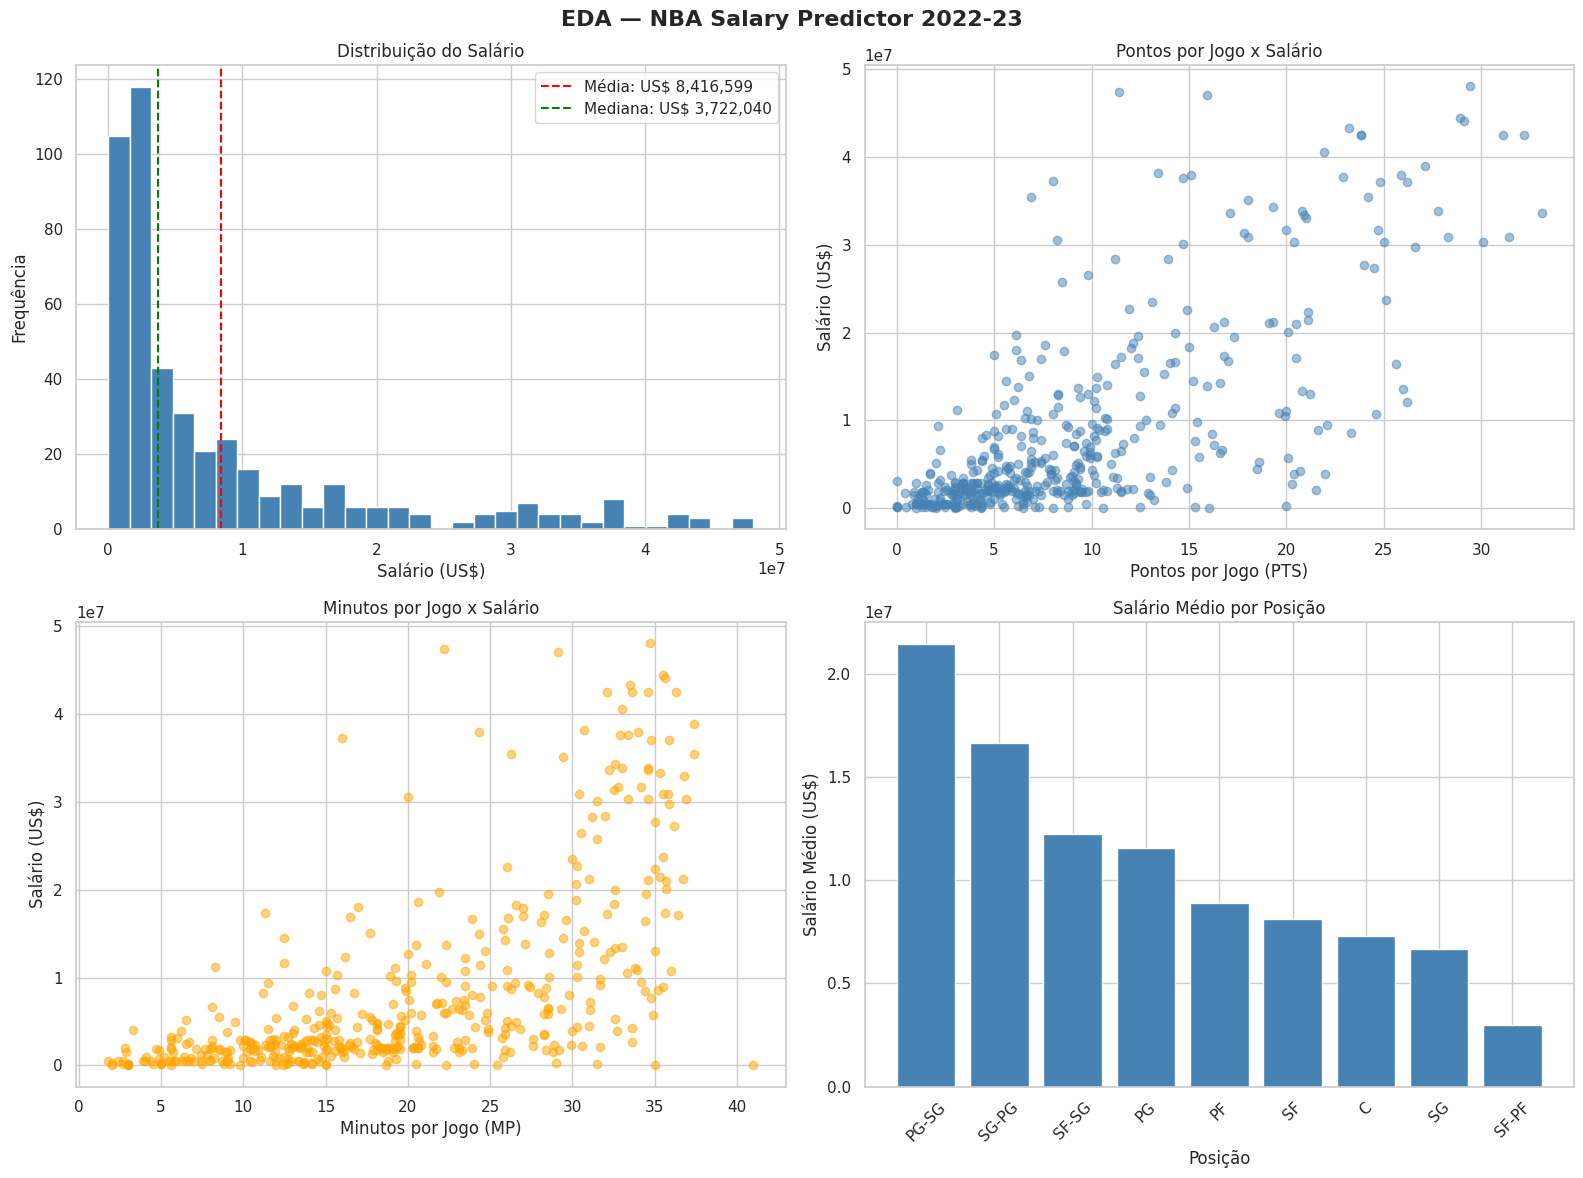

✅ Gráficos EDA gerados!


In [4]:
# ============================================================
# Célula 4: Fase 1 — Visualizações EDA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("EDA — NBA Salary Predictor 2022-23", fontsize=16, fontweight="bold")

# --------------------------------------------------------
# Gráfico 1: Distribuição do Salário (variável alvo)
# Mostra se a distribuição é simétrica ou assimétrica
# --------------------------------------------------------
axes[0, 0].hist(df["Salary"], bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribuição do Salário")
axes[0, 0].set_xlabel("Salário (US$)")
axes[0, 0].set_ylabel("Frequência")
axes[0, 0].axvline(df["Salary"].mean(), color="red", linestyle="--", label=f'Média: US$ {df["Salary"].mean():,.0f}')
axes[0, 0].axvline(df["Salary"].median(), color="green", linestyle="--", label=f'Mediana: US$ {df["Salary"].median():,.0f}')
axes[0, 0].legend()

# --------------------------------------------------------
# Gráfico 2: Dispersão PTS x Salary
# Mostra se jogadores que pontuam mais ganham mais
# --------------------------------------------------------
axes[0, 1].scatter(df["PTS"], df["Salary"], alpha=0.5, color="steelblue")
axes[0, 1].set_title("Pontos por Jogo x Salário")
axes[0, 1].set_xlabel("Pontos por Jogo (PTS)")
axes[0, 1].set_ylabel("Salário (US$)")

# --------------------------------------------------------
# Gráfico 3: Dispersão MP x Salary
# Mostra se jogadores que jogam mais minutos ganham mais
# --------------------------------------------------------
axes[1, 0].scatter(df["MP"], df["Salary"], alpha=0.5, color="orange")
axes[1, 0].set_title("Minutos por Jogo x Salário")
axes[1, 0].set_xlabel("Minutos por Jogo (MP)")
axes[1, 0].set_ylabel("Salário (US$)")

# --------------------------------------------------------
# Gráfico 4: Salário médio por posição
# Mostra qual posição tem maior remuneração
# --------------------------------------------------------
salary_position = df.groupby("Position")["Salary"].mean().sort_values(ascending=False)
axes[1, 1].bar(salary_position.index, salary_position.values, color="steelblue", edgecolor="white")
axes[1, 1].set_title("Salário Médio por Posição")
axes[1, 1].set_xlabel("Posição")
axes[1, 1].set_ylabel("Salário Médio (US$)")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("grafico_eda.png", dpi=120)
plt.show()
plt.close()
print("✅ Gráficos EDA gerados!")

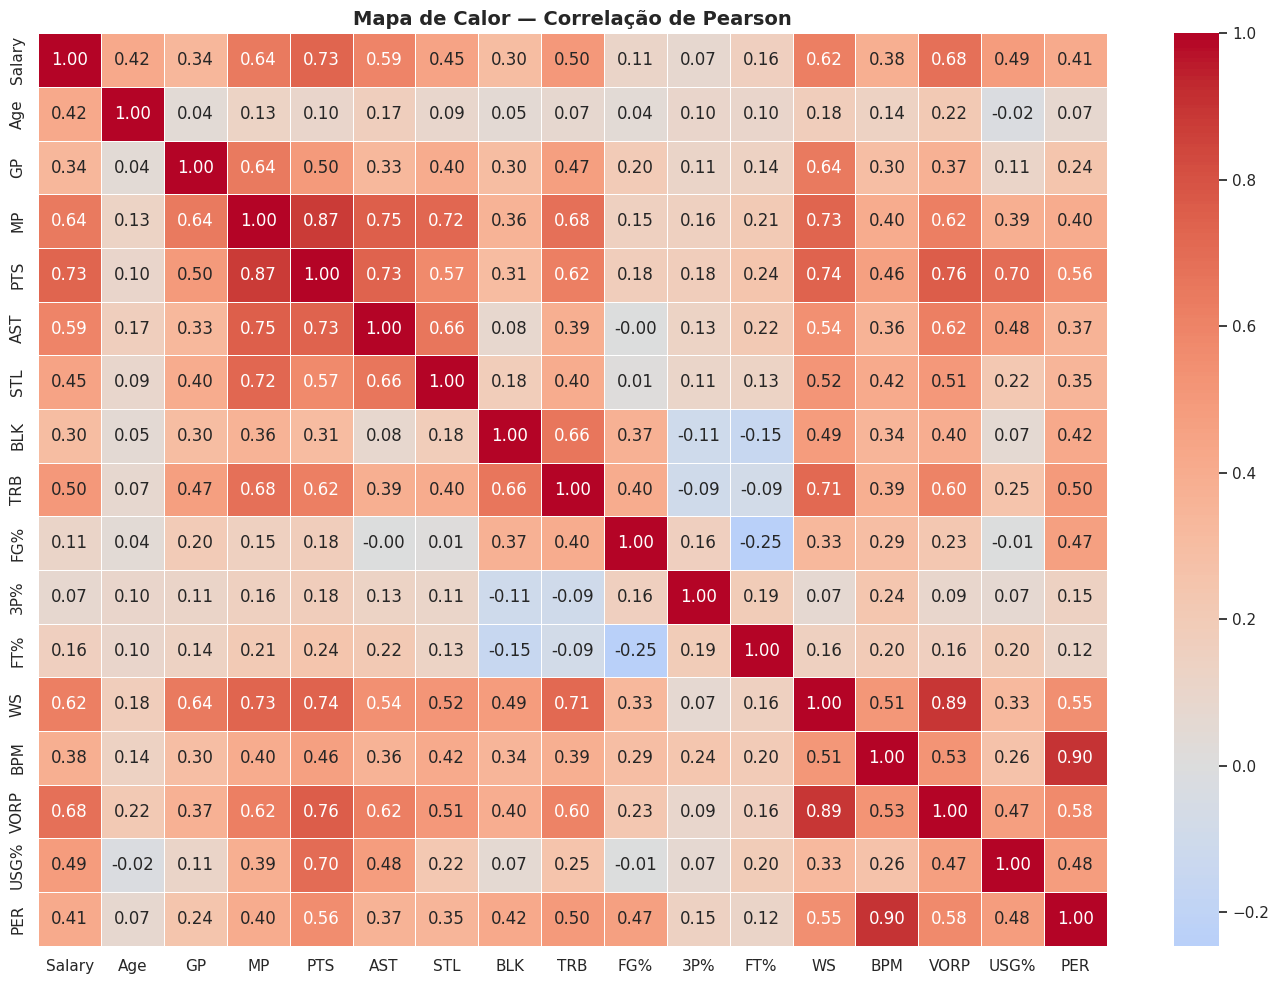

✅ Mapa de calor gerado!


In [5]:
# ============================================================
# Célula 5: Fase 1 — Mapa de Calor de Correlação
# ============================================================

# Selecionando as colunas mais relevantes para análise
# Evitamos colunas redundantes e focamos nas principais métricas
colunas_relevantes = [
    "Salary", "Age", "GP", "MP", "PTS", "AST",
    "STL", "BLK", "TRB", "FG%", "3P%", "FT%",
    "WS", "BPM", "VORP", "USG%", "PER"
]

# Calculando a correlação de Pearson entre as variáveis
correlacao = df[colunas_relevantes].corr()

# Plotando o mapa de calor
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    correlacao,
    annot=True,          # mostra os valores dentro das células
    fmt=".2f",           # formato com 2 casas decimais
    cmap="coolwarm",     # azul = correlação negativa, vermelho = positiva
    center=0,            # centro da escala de cores no zero
    linewidths=0.5,      # linhas entre as células
    ax=ax
)
ax.set_title("Mapa de Calor — Correlação de Pearson", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("grafico_correlacao.png", dpi=120)
plt.show()
plt.close()
print("✅ Mapa de calor gerado!")